# Notebook 03 — Trajectory Tangling & DMD Dynamics
**Input:** `results/02_geometry_{subj}.npz`  
**Output:** `results/03_dynamics_{subj}.npz`

**Analyses:**
1. Trajectory tangling Q(t): target vs. non-target (2-back)
2. DMD eigenspectrum: per-trial, maintenance window
3. Stability statistics: unit-circle distance by condition

**Key claim:** Target detection trials show elevated tangling at the detection moment,  
corresponding to a DMD eigenspectrum shift away from the unit circle.

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

sys.path.insert(0, str(Path('..').resolve() / 'src'))
from dynamics import (
    trial_tangling, mean_tangling_timecourse,
    maintenance_eigenspectra
)
from statistics import (
    permutation_test_twosample, bootstrap_ci_timecourse, temporal_cluster_permutation
)
from visualization import nature_style, fig3_tangling, fig4_eigenspectrum, save_figure, PALETTE
from preprocessing import SUBJECTS

nature_style()
RESULTS = Path('../results')
DT      = 1.0 / 1200   # seconds per sample
DMD_RANK = 6

## 1. Trajectory Tangling Q(t)

Q(t) = max_{t'} ‖Ż(t) - Ż(t')‖² / (‖Z(t) - Z(t')‖² + ε)

High Q at time t means the system is in a state where small differences in position
lead to large differences in velocity — the signature of dynamical instability.

Russo et al. (2018) showed motor cortex has uniformly low Q throughout movement.  
Here we test whether WM maintenance has elevated Q at target detection moments.

In [2]:
Q_tgt_all  = []
Q_ntgt_all = []

for subj in SUBJECTS:
    geo = np.load(RESULTS / f'02_geometry_{subj}.npz', allow_pickle=True)
    Z       = geo['Z']          # (N, T, k)
    task_id = geo['task_id']
    tgt_id  = geo['tgt_id']

    Q_trials = trial_tangling(Z, epsilon=1e-3, dt=DT)  # (N, T)

    mask_tgt  = (task_id == 2) & (tgt_id == 2)
    mask_ntgt = (task_id == 2) & (tgt_id == 1)

    if mask_tgt.sum() > 3:
        Q_tgt_all.append(Q_trials[mask_tgt])
    if mask_ntgt.sum() > 3:
        Q_ntgt_all.append(Q_trials[mask_ntgt])

    print(f'{subj}: tgt Q_peak = {Q_trials[mask_tgt].max(axis=1).mean():.2f}, '
          f'ntgt Q_peak = {Q_trials[mask_ntgt].max(axis=1).mean():.2f}')

# Pool across subjects
Q_tgt_pool  = np.vstack(Q_tgt_all)  if Q_tgt_all  else None
Q_ntgt_pool = np.vstack(Q_ntgt_all) if Q_ntgt_all else None

if Q_tgt_pool is not None and Q_ntgt_pool is not None:
    T_min = min(Q_tgt_pool.shape[1], Q_ntgt_pool.shape[1])
    Q_tgt_pool  = Q_tgt_pool[:, :T_min]
    Q_ntgt_pool = Q_ntgt_pool[:, :T_min]

    q_tgt_mean  = Q_tgt_pool.mean(0)
    q_ntgt_mean = Q_ntgt_pool.mean(0)

    # Peak Q comparison in maintenance window
    q_tgt_peak  = Q_tgt_pool.max(axis=1)
    q_ntgt_peak = Q_ntgt_pool.max(axis=1)
    stat, p = permutation_test_twosample(q_tgt_peak, q_ntgt_peak,
                                          alternative='greater', n_perm=5000)
    print(f'\nPeak Q: target vs non-target: Δ={stat:.3f}, p={p:.4f}')

al: tgt Q_peak = 738984.38, ntgt Q_peak = 748934.36


ca: tgt Q_peak = 997542.33, ntgt Q_peak = 679177.34


cc: tgt Q_peak = 842062.92, ntgt Q_peak = 796516.38


ug: tgt Q_peak = 923338.71, ntgt Q_peak = 920776.13

Peak Q: target vs non-target: Δ=103285.462, p=0.0422


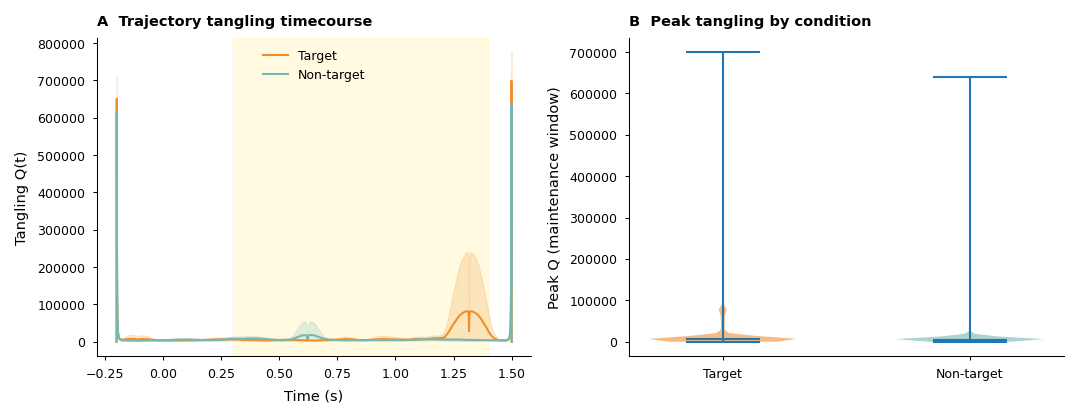

In [3]:
if Q_tgt_pool is not None:
    times = np.load(RESULTS / f'02_geometry_{SUBJECTS[0]}.npz')['times'][:T_min]

    _, q_tgt_lo, q_tgt_hi   = bootstrap_ci_timecourse(Q_tgt_pool, lambda x: np.mean(x, axis=0), n_boot=500)
    _, q_ntgt_lo, q_ntgt_hi = bootstrap_ci_timecourse(Q_ntgt_pool, lambda x: np.mean(x, axis=0), n_boot=500)

    fig = fig3_tangling(
        q_tgt_mean, q_ntgt_mean, times,
        ci_tgt=(q_tgt_lo, q_tgt_hi),
        ci_ntgt=(q_ntgt_lo, q_ntgt_hi),
    )
    save_figure(fig, 'fig3_tangling')
    plt.show()

## 2. DMD Eigenspectrum: System Stability by Condition

For each trial's maintenance window, fit an exact DMD model.  
Stable WM maintenance → eigenvalues near unit circle (|λ| ≈ 1).  
Target detection (comparison) moment → eigenvalues may drift (|λ| ≠ 1).

This analysis asks: does the linear approximation to local dynamics change  
between maintenance conditions?

al 2back_target: |λ|-dist from unit circle = 0.0006, max growth rate = 0.0016
al 2back_nontarget: |λ|-dist from unit circle = 0.0006, max growth rate = 0.0069
al 0back: |λ|-dist from unit circle = 0.0007, max growth rate = 0.0051
ca 2back_target: |λ|-dist from unit circle = 0.0013, max growth rate = 0.0086
ca 2back_nontarget: |λ|-dist from unit circle = 0.0009, max growth rate = 0.0132
ca 0back: |λ|-dist from unit circle = 0.0011, max growth rate = 0.0161


cc 2back_target: |λ|-dist from unit circle = 0.0007, max growth rate = 0.0054
cc 2back_nontarget: |λ|-dist from unit circle = 0.0008, max growth rate = 0.0163
cc 0back: |λ|-dist from unit circle = 0.0007, max growth rate = 0.0073
ug 2back_target: |λ|-dist from unit circle = 0.0006, max growth rate = 0.0061
ug 2back_nontarget: |λ|-dist from unit circle = 0.0008, max growth rate = 0.0076
ug 0back: |λ|-dist from unit circle = 0.0009, max growth rate = 0.0082


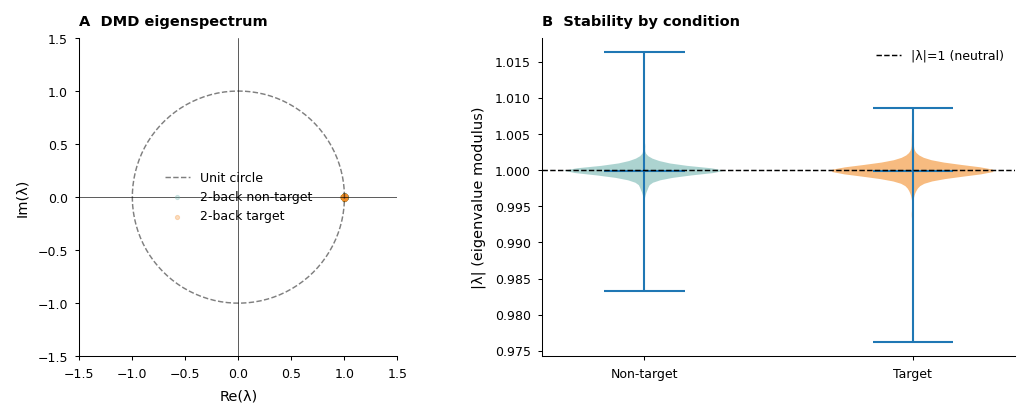


|λ| non-target vs target: Δ=0.0001, p=0.3488


In [4]:
all_evals_tgt  = []
all_evals_ntgt = []

for subj in SUBJECTS:
    geo     = np.load(RESULTS / f'02_geometry_{subj}.npz', allow_pickle=True)
    Z       = geo['Z']
    task_id = geo['task_id']
    tgt_id  = geo['tgt_id']
    times   = geo['times']

    spec = maintenance_eigenspectra(
        Z, times, task_id, tgt_id,
        maint_window=(0.3, 1.4), r=DMD_RANK, dt=DT
    )

    evals = spec['evals_by_condition']
    stab  = spec['stability_by_condition']

    for key, vals in stab.items():
        print(f'{subj} {key}: |λ|-dist from unit circle = '
              f"{vals['unit_circle_dist']:.4f}, max growth rate = {vals['max_growth_rate']:.4f}")

    if '2back_target' in evals:
        all_evals_tgt.append(evals['2back_target'])
    if '2back_nontarget' in evals:
        all_evals_ntgt.append(evals['2back_nontarget'])

if all_evals_tgt and all_evals_ntgt:
    evals_tgt_arr  = np.vstack(all_evals_tgt)
    evals_ntgt_arr = np.vstack(all_evals_ntgt)

    fig = fig4_eigenspectrum(evals_ntgt_arr, evals_tgt_arr)
    save_figure(fig, 'fig4_eigenspectrum')
    plt.show()

    # Compare |λ| distributions
    mod_tgt  = np.abs(evals_tgt_arr.ravel())
    mod_ntgt = np.abs(evals_ntgt_arr.ravel())
    stat, p = permutation_test_twosample(mod_ntgt, mod_tgt, n_perm=5000)
    print(f'\n|λ| non-target vs target: Δ={stat:.4f}, p={p:.4f}')

In [5]:
# Save pooled results for downstream notebooks
save_dict = {}
if Q_tgt_pool is not None:
    save_dict.update(dict(
        Q_tgt_pool=Q_tgt_pool.astype(np.float32),
        Q_ntgt_pool=Q_ntgt_pool.astype(np.float32),
    ))
if all_evals_tgt:
    save_dict.update(dict(
        evals_tgt=evals_tgt_arr,
        evals_ntgt=evals_ntgt_arr,
    ))
if save_dict:
    np.savez(RESULTS / '03_dynamics.npz', **save_dict)
    print('Saved → results/03_dynamics.npz')

Saved → results/03_dynamics.npz
